In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform

from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer, brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss
from scipy.stats import uniform

import xgboost as xgb

### How to Make a Custom Scorer

In [31]:
BrierScorer = make_scorer(brier_score_loss, greater_is_better=False, needs_proba=True)

### How to make a custom scorer
def rounded_RMSE(y_true, y_pred):
    rounded_preds = np.round(np.array(y_pred))
    return np.sqrt(np.mean((np.array(y_true) - rounded_preds) ** 2))

rounded_rmse_scorer = make_scorer(rounded_RMSE, greater_is_better=False)

c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


### How to Make a CV Split by Year

In [32]:
import pandas as pd
import os

# Assume root directory is './TrainingData'
root_dir = './TrainingData'

TRAIN_list = []
LABELS_list = []
fold_indices = []

SALE_COLUMNS = ["Actual Loss Calculation", "Zero Balance Removal UPB", "Net Sales Proceeds", 
                "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]

MISC_COLUMNS_TO_DROP = ["MSA", 'Postal Code', 
                        'Distress Date', 'Default Flag', 'Zero Balance Code', 'Unresolved', 'Last Time Current',
                         'Property State', 'Current Loan Delinquency Status', 'Loan Sequence Number']
CAT_COLUMNS = []

fold = 0 

# Load in all files from TrainingData Folder
for year_folder in sorted(os.listdir(root_dir)):
    year_path = os.path.join(root_dir, year_folder)
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                TRAIN_list.append(df.drop(columns=['Major Stress'])) 
                LABELS_list.append(df['Major Stress'])               
                fold_indices.extend([fold] * len(df))
        fold += 1

TRAIN = pd.concat(TRAIN_list).reset_index(drop=True)
TRAIN = TRAIN.drop(columns=SALE_COLUMNS)


In [33]:
TRAIN = TRAIN.drop(columns=MISC_COLUMNS_TO_DROP)
categorical_cols = TRAIN.select_dtypes(include=['object', 'category']).columns.tolist()

# Use below to add columns that we want dummies for but may not current be dtype categorical
# categorical_cols += CAT_COLUMNS

TRAIN = pd.get_dummies(TRAIN, columns=categorical_cols, drop_first=True)
LABELS = pd.concat(LABELS_list).reset_index(drop=True)
LABELS.fillna(0, inplace=True)

ps = PredefinedSplit(test_fold=fold_indices)



### How to Wrap XGB in a SKL Grid Search CVC
Scorer should be something like Brier Score or F1 (needs to account for the ridiculous imabalance and also should make sure probabilities are well calibrated)

In [35]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss
from scipy.stats import uniform

state = 40
NumParamSearchIterations = 20

# First split: TRAIN into Training+EarlyStopping and Final Validation sets
X_full_train, X_val, y_full_train, y_val = train_test_split(
    TRAIN, LABELS, test_size=0.2, random_state=state, stratify=LABELS
)

# Second split: split Training+EarlyStopping into Training and EarlyStopping
X_train, X_early_stop, y_train, y_early_stop = train_test_split(
    X_full_train, y_full_train, test_size=0.2, random_state=state, stratify=y_full_train
)

print(f"Train shape: {X_train.shape}, Early Stopping shape: {X_early_stop.shape}, Validation shape: {X_val.shape}")

# Expanded hyperparameter search space
param_distributions = {
    'n_estimators': range(100, 700),  # More trees
    'learning_rate': uniform(0.005, 0.05),  # Slower learning
    'max_depth': range(4, 15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'scale_pos_weight': range(400, 700)  # Tuning around class imbalance
}

# Setup RandomizedSearchCV
hyperparameter_tuning = RandomizedSearchCV(
    xgb.XGBClassifier(
        random_state=state,
        objective='binary:logistic',
        early_stopping_rounds=50,
        use_label_encoder=False,
    ),
    scoring='neg_brier_score',  # Focus on probability calibration
    param_distributions=param_distributions,
    n_iter=NumParamSearchIterations,
    cv=3,
    random_state=state,
    verbose=2,
    n_jobs=6
)

# Perform search with early stopping on the early_stop set
search = hyperparameter_tuning.fit(
    X_train, y_train,
    eval_set=[(X_early_stop, y_early_stop)],  # use early stopping set only
    verbose=True
)

# Output best results
print("\nBest Hyperparameters:", search.best_params_)
print("Best CV Brier Score (negated):", search.best_score_)

# Extract best model
best_model = search.best_estimator_

# Final validation predictions on untouched validation set
y_val_pred_probs = best_model.predict_proba(X_val)[:, 1]

# Final validation metrics
ap_score = average_precision_score(y_val, y_val_pred_probs)
brier = brier_score_loss(y_val, y_val_pred_probs)
logloss = log_loss(y_val, y_val_pred_probs)

print("\nValidation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")


Train shape: (902983, 45), Early Stopping shape: (225746, 45), Validation shape: (282183, 45)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[0]	validation_0-logloss:0.66929


c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\xgboost\core.py:158: UserWarning: [13:42:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[1]	validation_0-logloss:0.63448
[2]	validation_0-logloss:0.60243
[3]	validation_0-logloss:0.57373
[4]	validation_0-logloss:0.54645
[5]	validation_0-logloss:0.52171
[6]	validation_0-logloss:0.49853
[7]	validation_0-logloss:0.47758
[8]	validation_0-logloss:0.45837
[9]	validation_0-logloss:0.44126
[10]	validation_0-logloss:0.42379
[11]	validation_0-logloss:0.40647
[12]	validation_0-logloss:0.39166
[13]	validation_0-logloss:0.37807
[14]	validation_0-logloss:0.36399
[15]	validation_0-logloss:0.35143
[16]	validation_0-logloss:0.33996
[17]	validation_0-logloss:0.32876
[18]	validation_0-logloss:0.31831
[19]	validation_0-logloss:0.30834
[20]	validation_0-logloss:0.29858
[21]	validation_0-logloss:0.28969
[22]	validation_0-logloss:0.28134
[23]	validation_0-logloss:0.27384
[24]	validation_0-logloss:0.26681
[25]	validation_0-logloss:0.25983
[26]	validation_0-logloss:0.25385
[27]	validation_0-logloss:0.24800
[28]	validation_0-logloss:0.24172
[29]	validation_0-logloss:0.23531
[30]	validation_0-loglo

In [38]:


# Your best hyperparameters
best_params = {
    'colsample_bytree': 0.7933654960298453,
    'learning_rate': 0.05443805744913271,
    'max_depth': 10,
    'n_estimators': 550,
    'scale_pos_weight': 491,
    'subsample': 0.7208934261456471,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss'
}

# Number of models
n_models = 10

# Seeds to use
seeds = np.arange(60, 60 + n_models)

# Store all fitted models
models = []

# Train models
for seed in seeds:
    model = xgb.XGBClassifier(**best_params, random_state=seed, early_stopping_rounds=50)
    model.fit(
        X_train, y_train,
        eval_set=[(X_early_stop, y_early_stop)],
        verbose=False
    )
    models.append(model)

# Predict: average the probabilities across all models
all_preds = np.zeros(X_val.shape[0])

for model in models:
    preds = model.predict_proba(X_val)[:, 1]
    all_preds += preds

ensemble_preds = all_preds / n_models  # Average

# Evaluate ensemble
ap_score = average_precision_score(y_val, ensemble_preds)
brier = brier_score_loss(y_val, ensemble_preds)
logloss = log_loss(y_val, ensemble_preds)

print("\nEnsemble Validation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")


c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\xgboost\core.py:158: UserWarning: [13:50:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\xgboost\core.py:158: UserWarning: [13:51:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\xgboost\core.py:158: UserWarning: [13:52:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserW


Ensemble Validation Metrics:
Average Precision Score: 0.3079
Brier Score: 0.002054
Log Loss: 0.011386

Calibration Summary by Probability Bin:
  prob_bin  samples    percent  distress_rate
0    0-0.1   280565  99.426613       0.001087
1  0.1-0.2      670   0.237435       0.052239
2  0.2-0.3      244   0.086469       0.065574
3  0.3-0.4      136   0.048196       0.125000
4  0.4-0.5       98   0.034729       0.153061
5  0.5-0.6       69   0.024452       0.130435
6  0.6-0.7       69   0.024452       0.173913
7  0.7-0.8       49   0.017365       0.265306
8  0.8-0.9       71   0.025161       0.394366
9  0.9-1.0      212   0.075129       0.660377


C:\Users\seanv\AppData\Local\Temp\ipykernel_31940\3919134589.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = results_df.groupby('prob_bin').agg(


In [ ]:

# Calibration evaluation
results_df = pd.DataFrame({
    'y_true': y_val,
    'y_pred_prob': ensemble_preds
})

# Define probability bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
results_df['prob_bin'] = pd.cut(results_df['y_pred_prob'], bins=bins, labels=labels, include_lowest=True)

# Group by bins
bin_summary = results_df.groupby('prob_bin').agg(
    samples=('y_true', 'count'),
    percent=('y_true', lambda x: len(x) / len(results_df) * 100),
    distress_rate=('y_true', 'mean')
).reset_index()

print("\nCalibration Summary by Probability Bin:")
print(bin_summary)


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    'y_true': y_val,
    'y_pred_prob': y_val_pred_probs
})

# Define probability bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
results_df['prob_bin'] = pd.cut(results_df['y_pred_prob'], bins=bins, labels=labels, include_lowest=True)

# Group by bins
bin_summary = results_df.groupby('prob_bin').agg(
    samples=('y_true', 'count'),
    percent=('y_true', lambda x: len(x) / len(results_df) * 100),
    distress_rate=('y_true', 'mean')
).reset_index()


print(bin_summary)


  prob_bin  samples    percent  distress_rate
0    0-0.1   281110  99.619750       0.001195
1  0.1-0.2      356   0.126159       0.073034
2  0.2-0.3      154   0.054575       0.097403
3  0.3-0.4       86   0.030477       0.139535
4  0.4-0.5       60   0.021263       0.166667
5  0.5-0.6       57   0.020200       0.140351
6  0.6-0.7       47   0.016656       0.276596
7  0.7-0.8       46   0.016301       0.260870
8  0.8-0.9       53   0.018782       0.339623
9  0.9-1.0      214   0.075837       0.654206


C:\Users\seanv\AppData\Local\Temp\ipykernel_31940\3055058798.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = results_df.groupby('prob_bin').agg(


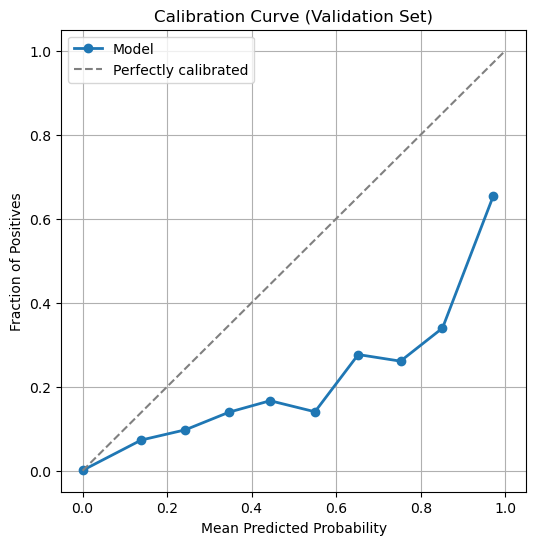

In [37]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Compute calibration curve
# (true labels, predicted probabilities, and number of bins)
true_probs, pred_probs = calibration_curve(y_val, y_val_pred_probs, n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(6, 6))
plt.plot(pred_probs, true_probs, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.title('Calibration Curve (Validation Set)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_bin_performance_by_delinquency(df, prob_col="predicted_probability", delinquency_col="Numeric Delinquency", outcome_col="Default Flag"):
    bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    labels = ["0-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5",
              "0.5-0.6", "0.6-0.7", "0.7-0.8", "0.8-0.9", "0.9-1.0"]

    df["prob_bin"] = pd.cut(df[prob_col], bins=bins, labels=labels, include_lowest=True)

    delinquency_levels = sorted(df[delinquency_col].dropna().unique())

    for level in delinquency_levels:
        subset = df[df[delinquency_col] == level]

        if subset.empty:
            continue

        bin_summary = subset.groupby("prob_bin").agg(
            samples=(outcome_col, "count"),
            distress_rate=(outcome_col, "mean")
        ).reset_index()

        bin_summary = bin_summary[bin_summary["samples"] > 0]

        if bin_summary.empty:
            continue

        fig, ax1 = plt.subplots(figsize=(9, 5))

        ax1.bar(bin_summary["prob_bin"], bin_summary["samples"], alpha=0.6, label="Samples", width=0.6, color="skyblue")
        ax1.set_ylabel("Number of Samples", color="blue")
        ax1.set_xlabel("Predicted Probability Bin")
        ax1.set_title(f"Delinquency Level: {level}")
        ax1.tick_params(axis='y', labelcolor="blue")

        # Add sample counts above bars
        for idx, row in bin_summary.iterrows():
            ax1.text(idx, row["samples"] + max(bin_summary["samples"]) * 0.01, str(int(row["samples"])),
                     ha='center', va='bottom', fontsize=8)

        ax2 = ax1.twinx()
        ax2.plot(bin_summary["prob_bin"], bin_summary["distress_rate"], color="red", marker="o", markersize=6, label="Distress Rate")
        ax2.set_ylabel("Distress Rate", color="red")
        ax2.tick_params(axis='y', labelcolor="red")
        ax2.set_ylim(0, 1)  # set distress rate 0-1 scale

        plt.tight_layout()
        plt.show()


# Example usage:
# Prepare validation DataFrame
X_val_with_preds = X_val.copy()
X_val_with_preds["predicted_probability"] = y_val_pred_probs
X_val_with_preds["Default Flag"] = y_val

# Now pass it in
plot_bin_performance_by_delinquency(X_val_with_preds)


In [ ]:
import pandas as pd

# Pull feature importance scores
booster = best_model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

# Convert to DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance (Gain)': list(importance_dict.values())
}).sort_values(by='Importance (Gain)', ascending=False)

print(importance_df)
